# When customers explicitly cancel: BTYD vs churn vs survival

In the BTYD notebook we said:

> If customers explicitly cancel, survival models or churn models may be a better first choice.

This notebook explains that statement deeply, with a synthetic subscription example.

We will compare three modeling mindsets:

| Model family | Best question | Typical data situation |
|---|---|---|
| BTYD / `lifetimes` | How many future repeat purchases will a non-contractual customer make? | Retail customers silently stop buying; no cancellation event exists. |
| Churn classifier | Will this active customer churn in a fixed future window? | Business wants a yes/no campaign target for next 30/60/90 days. |
| Survival model | When will this active customer churn, accounting for censoring? | Business cares about timing and not everyone has churned yet. |

The punchline will be visible in code: for a contractual subscription business, BTYD answers the wrong question and performs much worse as a churn-risk model.

## 1. The core distinction

A non-contractual retail customer can disappear without telling you. If they stop buying coffee, you do not know whether they are gone or just waiting until next month. That is where BTYD shines.

A contractual subscriber can explicitly cancel. You usually know the cancellation date. That changes the problem.

For subscriptions, monthly invoices are not spontaneous purchases. They are generated by the contract. A customer can look like a perfect repeat buyer until the day they cancel.

That is why BTYD can look technically valid but be strategically wrong.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes import BetaGeoFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from lifelines import CoxPHFitter, KaplanMeierFitter

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704
rng = np.random.default_rng(RANDOM_SEED)

## 2. Story: a SaaS company with explicit cancellations

Imagine a B2B SaaS company.

Every active customer receives a monthly invoice. Some customers eventually submit a cancellation request. At the prediction date, the customer success team wants to know:

> Which currently active customers are likely to cancel in the next 90 days?

We will generate synthetic data with features known at the prediction date:

- plan type
- annual contract flag
- seats
- monthly fee
- onboarding score
- last-30-day usage
- support tickets
- payment failures
- NPS-like score

These are exactly the kinds of signals a churn or survival model can use. BTYD, in its standard form, mostly sees invoice timing.

In [2]:
def simulate_subscription_customers(n_customers=4500):
    landmark = pd.Timestamp("2025-01-01")
    study_end = pd.Timestamp("2025-12-31")
    signup_start = pd.Timestamp("2023-01-01")
    signup_end = pd.Timestamp("2024-10-01")

    signup_date = signup_start + pd.to_timedelta(
        rng.integers(0, (signup_end - signup_start).days, n_customers), unit="D"
    )
    plan = rng.choice(["Starter", "Growth", "Enterprise"], n_customers, p=[0.48, 0.38, 0.14])
    annual_contract = rng.binomial(1, 0.18 + 0.28 * (plan == "Enterprise") + 0.10 * (plan == "Growth"))
    seats = np.round(
        rng.lognormal(1.4 + 0.3 * (plan == "Growth") + 0.8 * (plan == "Enterprise"), 0.55)
    ).astype(int).clip(1, 250)
    monthly_fee = 29 + 35 * (plan == "Growth") + 180 * (plan == "Enterprise") + seats * rng.uniform(3, 9, n_customers)

    onboarding_score = (45 + 13 * (plan != "Starter") + 9 * annual_contract + rng.normal(0, 16, n_customers)).clip(0, 100)
    usage_last_30 = rng.poisson(
        np.maximum(1, 5 + 5 * (plan == "Growth") + 8 * (plan == "Enterprise") + 0.20 * onboarding_score - 3 * (annual_contract == 0))
    ).clip(0, 60)
    support_tickets_90 = rng.poisson(0.7 + 0.8 * (plan == "Starter") + 0.04 * np.maximum(seats - 15, 0))
    payment_failures_90 = rng.binomial(2, 0.035 + 0.06 * (plan == "Starter") + 0.03 * (annual_contract == 0))
    nps_score = (
        45 + 0.7 * onboarding_score + 0.5 * usage_last_30 - 7 * support_tickets_90 - 15 * payment_failures_90 + rng.normal(0, 18, n_customers)
    ).clip(0, 100)

    # Daily cancellation hazard. The signs are intentionally intuitive:
    # low usage, poor onboarding, support friction, and payment failures increase cancellation risk.
    log_rate = (
        -5.55
        + 0.85 * (plan == "Starter")
        - 0.45 * (plan == "Enterprise")
        - 0.60 * annual_contract
        - 0.022 * onboarding_score
        - 0.035 * usage_last_30
        + 0.28 * support_tickets_90
        + 0.72 * payment_failures_90
        - 0.011 * nps_score
        + 0.002 * np.minimum(monthly_fee, 500)
    )
    rate = np.exp(log_rate)
    theoretical_cancel_days = np.ceil(rng.exponential(1 / rate)).astype(float)
    max_observable_days = (study_end - signup_date).days
    event_observed = theoretical_cancel_days <= max_observable_days
    safe_cancel_days = np.minimum(theoretical_cancel_days, max_observable_days + 1).astype(int)
    cancel_date_raw = signup_date + pd.to_timedelta(safe_cancel_days, unit="D")
    cancel_date = pd.Series(cancel_date_raw).where(event_observed, pd.NaT)

    customers = pd.DataFrame(
        {
            "customer_id": [f"S{i:05d}" for i in range(n_customers)],
            "signup_date": signup_date,
            "plan": plan,
            "annual_contract": annual_contract,
            "seats": seats,
            "monthly_fee": monthly_fee.round(2),
            "onboarding_score": onboarding_score.round(1),
            "usage_last_30": usage_last_30,
            "support_tickets_90": support_tickets_90,
            "payment_failures_90": payment_failures_90,
            "nps_score": nps_score.round(1),
            "cancel_date": cancel_date,
            "event_observed_full_study": event_observed.astype(int),
        }
    )
    return customers, landmark, study_end

customers, landmark, study_end = simulate_subscription_customers()
customers.head()

,customer_id,signup_date,plan,annual_contract,seats,monthly_fee,onboarding_score,usage_last_30,support_tickets_90,payment_failures_90,nps_score,cancel_date,event_observed_full_study
0,S00000,2023-01-02,Growth,0,3,75.24,72.9,17,1,1,80.4,2025-12-27,1
1,S00001,2024-03-15,Starter,1,3,50.29,54.1,16,1,0,90.9,NaT,0
2,S00002,2023-08-31,Growth,0,8,115.85,80.9,31,0,0,100.0,NaT,0
3,S00003,2024-01-03,Enterprise,1,1,215.90,45.4,21,1,0,83.4,NaT,0
4,S00004,2023-05-25,Starter,0,5,47.05,58.5,12,3,0,55.3,NaT,0


In [3]:
active = customers[
    (customers["signup_date"] < landmark - pd.Timedelta(days=60))
    & (customers["cancel_date"].isna() | (customers["cancel_date"] > landmark))
].copy()

active["event_after_landmark"] = active["cancel_date"].notna().astype(int)
active["time_from_landmark"] = np.where(
    active["cancel_date"].notna(),
    (active["cancel_date"] - landmark).dt.days,
    (study_end - landmark).days,
).clip(1)
active["churn_90d"] = (
    active["cancel_date"].notna() & (active["cancel_date"] <= landmark + pd.Timedelta(days=90))
).astype(int)

print(f"Prediction date: {landmark.date()}")
print(f"Study end:       {study_end.date()}")
print(f"Active customers at prediction date: {len(active):,}")
print(f"Cancel later during study: {active['event_after_landmark'].mean():.1%}")
print(f"Cancel within next 90 days: {active['churn_90d'].mean():.1%}")

active[["signup_date", "plan", "annual_contract", "usage_last_30", "support_tickets_90", "payment_failures_90", "cancel_date", "time_from_landmark", "churn_90d"]].head()

Prediction date: 2025-01-01
Study end:       2025-12-31
Active customers at prediction date: 3,111
Cancel later during study: 20.2%
Cancel within next 90 days: 5.9%


,signup_date,plan,annual_contract,usage_last_30,support_tickets_90,payment_failures_90,cancel_date,time_from_landmark,churn_90d
0,2023-01-02,Growth,0,17,1,1,2025-12-27,360.0,0
1,2024-03-15,Starter,1,16,1,0,NaT,364.0,0
2,2023-08-31,Growth,0,31,0,0,NaT,364.0,0
3,2024-01-03,Enterprise,1,21,1,0,NaT,364.0,0
4,2023-05-25,Starter,0,12,3,0,NaT,364.0,0


## 3. Build the mechanical invoice table

For a subscription company, invoices happen because the contract is active.

That is the key difference from non-contractual retail:

- Retail order: the customer decided to buy today.
- Subscription invoice: the billing system charged them because they had not canceled yet.

BTYD treats observed repeat purchases as behavioral purchase events. For subscriptions, those events are partly mechanical.

In [4]:
def generate_monthly_invoices(active_customers, landmark):
    rows = []
    for _, row in active_customers.iterrows():
        invoice_date = row["signup_date"]
        month_index = 0
        while invoice_date <= landmark:
            rows.append(
                {
                    "customer_id": row["customer_id"],
                    "invoice_date": invoice_date,
                    "sales_value": row["monthly_fee"],
                }
            )
            month_index += 1
            invoice_date = row["signup_date"] + pd.DateOffset(months=month_index)
    return pd.DataFrame(rows)

invoices = generate_monthly_invoices(active, landmark)
print(invoices.shape)
invoices.head()

(41485, 3)


,customer_id,invoice_date,sales_value
0,S00000,2023-01-02,75.24
1,S00000,2023-02-02,75.24
2,S00000,2023-03-02,75.24
3,S00000,2023-04-02,75.24
4,S00000,2023-05-02,75.24


In [5]:
invoice_summary = invoices.groupby("customer_id").agg(
    first_invoice=("invoice_date", "min"),
    last_invoice=("invoice_date", "max"),
    invoice_count=("invoice_date", "count"),
    avg_invoice=("sales_value", "mean"),
).reset_index()
invoice_summary = invoice_summary.merge(active[["customer_id", "churn_90d"]], on="customer_id", how="left")
invoice_summary.groupby("churn_90d")[["invoice_count", "avg_invoice"]].mean().round(2)

,invoice_count,avg_invoice
churn_90d,,
0,13.37,117.60
1,12.74,80.76


## 4. Train/test split

All models will be evaluated on the same held-out active customers.

The label for the churn classifier is fixed-horizon:

> Did the active customer cancel within 90 days after the landmark date?

The survival model uses more information:

> How many days after the landmark until cancellation, or until censoring at study end?

The BTYD baseline only sees pre-landmark invoice timing.

In [6]:
train_idx, test_idx = train_test_split(
    active.index,
    test_size=0.35,
    random_state=42,
    stratify=active["churn_90d"],
)
train = active.loc[train_idx].copy()
test = active.loc[test_idx].copy()

print("train:", train.shape, "90d churn rate:", round(train["churn_90d"].mean(), 3))
print("test: ", test.shape, "90d churn rate:", round(test["churn_90d"].mean(), 3))

train: (2022, 16) 90d churn rate: 0.059
test:  (1089, 16) 90d churn rate: 0.06


## 5. BTYD baseline with `lifetimes`

We deliberately use BTYD as a baseline so we can see why it is the wrong first tool here.

BTYD receives only the subscription invoice history before the landmark date. It does not receive the explicit cancellation date or customer health features.

Because every active subscriber has recent regular invoices, the model tends to conclude they are alive.

In [7]:
def build_subscription_rfm(invoice_df, observation_end):
    grouped = invoice_df.groupby("customer_id").agg(
        first_invoice=("invoice_date", "min"),
        last_invoice=("invoice_date", "max"),
        invoice_count=("invoice_date", "count"),
        monetary_value=("sales_value", "mean"),
    )
    rfm = pd.DataFrame(index=grouped.index)
    rfm["frequency"] = (grouped["invoice_count"] - 1).astype(float)
    rfm["recency"] = (grouped["last_invoice"] - grouped["first_invoice"]).dt.days.astype(float)
    rfm.loc[rfm["frequency"].eq(0), "recency"] = 0.0
    rfm["T"] = (observation_end - grouped["first_invoice"]).dt.days.astype(float)
    rfm["monetary_value"] = grouped["monetary_value"].astype(float)
    if not (rfm["recency"] <= rfm["T"]).all():
        raise ValueError("RFM definition error: recency must be <= T")
    return rfm

rfm_observation_end = landmark + pd.Timedelta(days=1)
train_invoices = invoices[invoices["customer_id"].isin(train["customer_id"])]
rfm_train = build_subscription_rfm(train_invoices, rfm_observation_end)
rfm_all = build_subscription_rfm(invoices, rfm_observation_end)

bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(rfm_train["frequency"], rfm_train["recency"], rfm_train["T"])

rfm_test = rfm_all.loc[test["customer_id"]]
btyd_p_alive = bgf.conditional_probability_alive(rfm_test["frequency"], rfm_test["recency"], rfm_test["T"])
btyd_expected_invoices_90d = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    rfm_test["frequency"],
    rfm_test["recency"],
    rfm_test["T"],
)

btyd_eval = test[["customer_id", "churn_90d"]].copy()
btyd_eval["btyd_p_alive"] = np.asarray(btyd_p_alive)
btyd_eval["btyd_expected_invoices_90d"] = np.asarray(btyd_expected_invoices_90d)
btyd_eval.head()

,customer_id,churn_90d,btyd_p_alive,btyd_expected_invoices_90d
3256,S03256,0,1.0,2.864443
3484,S03484,0,1.0,2.921667
516,S00516,0,1.0,2.835707
4110,S04110,0,1.0,2.927137
3405,S03405,0,1.0,2.873032


In [8]:
print("BTYD P(alive) distribution")
display(btyd_eval["btyd_p_alive"].describe().round(4).to_frame())
print("BTYD expected invoice count in next 90 days")
display(btyd_eval["btyd_expected_invoices_90d"].describe().round(4).to_frame())

btyd_auc_palive = roc_auc_score(btyd_eval["churn_90d"], 1 - btyd_eval["btyd_p_alive"])
btyd_auc_expected = roc_auc_score(btyd_eval["churn_90d"], -btyd_eval["btyd_expected_invoices_90d"])
print(f"BTYD AUC using 1 - P(alive): {btyd_auc_palive:.3f}")
print(f"BTYD AUC using -expected invoices: {btyd_auc_expected:.3f}")

BTYD P(alive) distribution


,btyd_p_alive
count,1089.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


BTYD expected invoice count in next 90 days


,btyd_expected_invoices_90d
count,1089.0000
mean,2.7931
std,0.1074
min,2.3827
25%,2.7455
50%,2.8214
75%,2.8688
max,2.9427


BTYD AUC using 1 - P(alive): 0.500
BTYD AUC using -expected invoices: 0.548


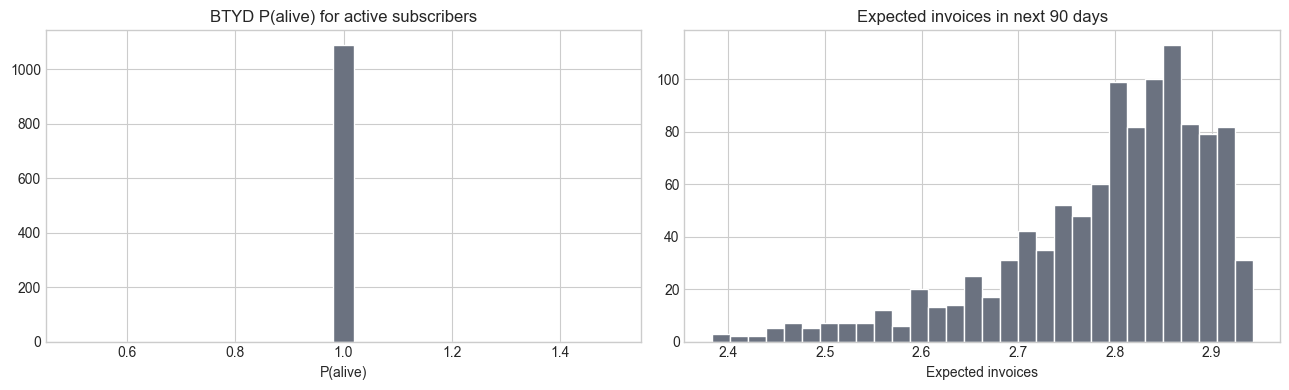

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(btyd_eval["btyd_p_alive"], bins=25, color="#6B7280", edgecolor="white")
axes[0].set_title("BTYD P(alive) for active subscribers")
axes[0].set_xlabel("P(alive)")
axes[1].hist(btyd_eval["btyd_expected_invoices_90d"], bins=30, color="#6B7280", edgecolor="white")
axes[1].set_title("Expected invoices in next 90 days")
axes[1].set_xlabel("Expected invoices")
plt.tight_layout()
plt.show()

## What just happened?

BTYD is not broken. It is answering a different question.

All customers in the evaluation set are active subscribers at the landmark date. They have regular invoices. So standard BTYD sees a clean purchase stream and says, effectively:

> These customers look alive.

But the business question is:

> Which active subscribers are about to submit an explicit cancellation request?

That requires customer health, usage, support, payment, and contract features.

## 6. Churn model: fixed-horizon cancellation risk

A churn classifier converts the question into a yes/no target:

> Will the customer cancel in the next 90 days?

This is often the right first model when the business needs a campaign list for a fixed window.

It does not model the full timing curve. It only models one horizon.

In [10]:
feature_cols = [
    "plan",
    "annual_contract",
    "seats",
    "monthly_fee",
    "onboarding_score",
    "usage_last_30",
    "support_tickets_90",
    "payment_failures_90",
    "nps_score",
]

X_train = pd.get_dummies(train[feature_cols], drop_first=True)
X_test = pd.get_dummies(test[feature_cols], drop_first=True).reindex(columns=X_train.columns, fill_value=0)
y_train = train["churn_90d"]
y_test = test["churn_90d"]

churn_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.04,
    max_leaf_nodes=15,
    l2_regularization=0.05,
    random_state=42,
)
churn_model.fit(X_train, y_train)
churn_proba = churn_model.predict_proba(X_test)[:, 1]

churn_auc = roc_auc_score(y_test, churn_proba)
churn_pr_auc = average_precision_score(y_test, churn_proba)
print(f"Churn classifier ROC-AUC: {churn_auc:.3f}")
print(f"Churn classifier PR-AUC:  {churn_pr_auc:.3f}")

Churn classifier ROC-AUC: 0.717
Churn classifier PR-AUC:  0.138


In [11]:
churn_eval = test[["customer_id", "plan", "usage_last_30", "support_tickets_90", "payment_failures_90", "churn_90d"]].copy()
churn_eval["churn_model_risk_90d"] = churn_proba
churn_eval.sort_values("churn_model_risk_90d", ascending=False).head(12).round(3)

,customer_id,plan,usage_last_30,support_tickets_90,payment_failures_90,churn_90d,churn_model_risk_90d
3418,S03418,Enterprise,12,1,1,0,0.717
933,S00933,Starter,9,1,1,0,0.710
1078,S01078,Starter,8,0,0,0,0.633
4476,S04476,Starter,6,0,0,1,0.558
4021,S04021,Starter,6,1,0,0,0.532
600,S00600,Starter,7,0,0,0,0.527
378,S00378,Starter,10,1,1,0,0.513
1317,S01317,Starter,9,1,1,0,0.486
4493,S04493,Starter,6,1,1,1,0.459
3599,S03599,Starter,11,3,0,0,0.451


## 7. Survival model: time-to-cancel with censoring

A survival model keeps the clock.

For every active customer at the landmark date, we define:

- `time_from_landmark`: days until cancellation, or days until study end if still active.
- `event_after_landmark`: 1 if cancellation was observed, 0 if censored.

This lets us estimate probabilities for many horizons:

- churn by 30 days
- churn by 90 days
- churn by 180 days
- expected retention curve

That is the key difference from a churn classifier.

In [12]:
cox_train = pd.concat(
    [X_train.reset_index(drop=True), train[["time_from_landmark", "event_after_landmark"]].reset_index(drop=True)],
    axis=1,
)
cox_test = pd.concat(
    [X_test.reset_index(drop=True), test[["time_from_landmark", "event_after_landmark"]].reset_index(drop=True)],
    axis=1,
)

cph = CoxPHFitter(penalizer=0.05)
cph.fit(cox_train, duration_col="time_from_landmark", event_col="event_after_landmark")

cox_cindex = cph.score(cox_test, scoring_method="concordance_index")
cox_churn_90d = 1 - cph.predict_survival_function(X_test, times=[90]).T[90]
cox_horizon_auc = roc_auc_score(y_test, cox_churn_90d)

print(f"Cox survival test concordance: {cox_cindex:.3f}")
print(f"Cox-derived 90-day churn ROC-AUC: {cox_horizon_auc:.3f}")
cph.summary[["coef", "exp(coef)", "p"]].sort_values("p").round(3).head(10)

Cox survival test concordance: 0.755
Cox-derived 90-day churn ROC-AUC: 0.796


,coef,exp(coef),p
covariate,,,
payment_failures_90,0.627,1.872,0.000
support_tickets_90,0.226,1.254,0.000
nps_score,-0.013,0.987,0.000
usage_last_30,-0.037,0.964,0.000
onboarding_score,-0.014,0.986,0.000
annual_contract,-0.340,0.712,0.002
plan_Starter,0.421,1.524,0.005
plan_Growth,-0.233,0.792,0.080
monthly_fee,-0.001,0.999,0.103


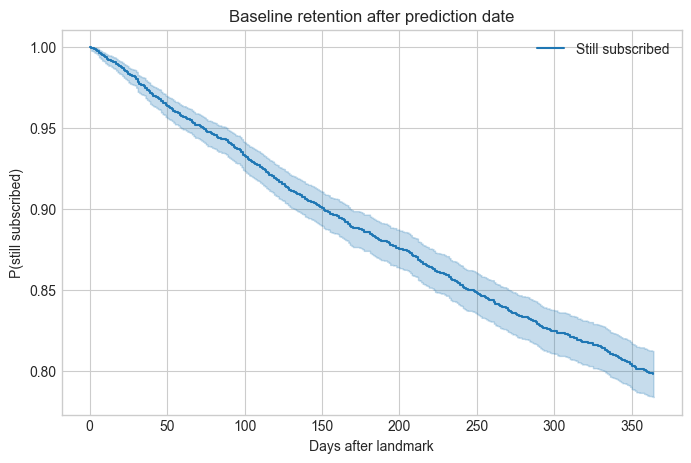

In [13]:
kmf = KaplanMeierFitter()
kmf.fit(active["time_from_landmark"], active["event_after_landmark"], label="Still subscribed")
ax = kmf.plot_survival_function(figsize=(8, 5))
ax.set_title("Baseline retention after prediction date")
ax.set_xlabel("Days after landmark")
ax.set_ylabel("P(still subscribed)")
plt.show()

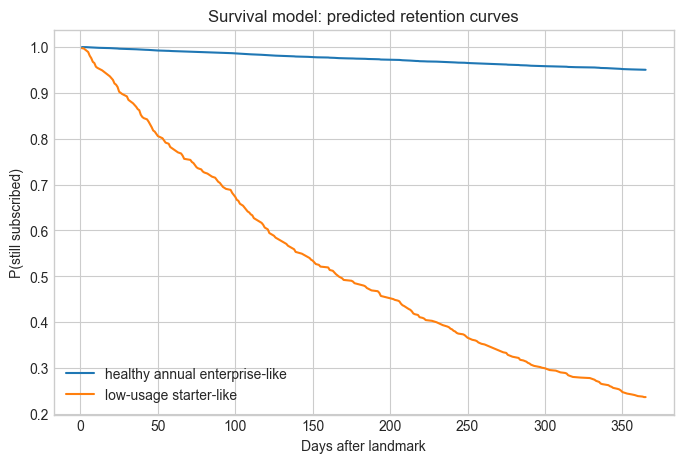

,profile,churn_by_30d,churn_by_90d,churn_by_180d
0,healthy annual enterprise-like,0.004,0.012,0.025
1,low-usage starter-like,0.108,0.296,0.518


In [14]:
low_risk = X_test.median().to_frame().T
high_risk = X_test.median().to_frame().T

# Build two illustrative profiles in the encoded feature space.
for col in X_test.columns:
    if col.startswith("plan_"):
        low_risk[col] = 0
        high_risk[col] = 0
if "plan_Enterprise" in X_test.columns:
    low_risk["plan_Enterprise"] = 1
if "plan_Starter" in X_test.columns:
    high_risk["plan_Starter"] = 1

low_risk["annual_contract"] = 1
low_risk["usage_last_30"] = X_test["usage_last_30"].quantile(0.85)
low_risk["support_tickets_90"] = 0
low_risk["payment_failures_90"] = 0
low_risk["onboarding_score"] = X_test["onboarding_score"].quantile(0.85)
low_risk["nps_score"] = X_test["nps_score"].quantile(0.85)

high_risk["annual_contract"] = 0
high_risk["usage_last_30"] = X_test["usage_last_30"].quantile(0.10)
high_risk["support_tickets_90"] = X_test["support_tickets_90"].quantile(0.90)
high_risk["payment_failures_90"] = 1
high_risk["onboarding_score"] = X_test["onboarding_score"].quantile(0.15)
high_risk["nps_score"] = X_test["nps_score"].quantile(0.15)

profiles = pd.concat([low_risk, high_risk], ignore_index=True)
profiles.index = ["healthy annual enterprise-like", "low-usage starter-like"]
curves = cph.predict_survival_function(profiles, times=np.arange(1, 366))
ax = curves.plot(figsize=(8, 5))
ax.set_title("Survival model: predicted retention curves")
ax.set_xlabel("Days after landmark")
ax.set_ylabel("P(still subscribed)")
plt.show()

pd.DataFrame(
    {
        "profile": profiles.index,
        "churn_by_30d": (1 - cph.predict_survival_function(profiles, times=[30]).T[30]).round(3).values,
        "churn_by_90d": (1 - cph.predict_survival_function(profiles, times=[90]).T[90]).round(3).values,
        "churn_by_180d": (1 - cph.predict_survival_function(profiles, times=[180]).T[180]).round(3).values,
    }
)

## 8. Head-to-head comparison

We evaluated all models on the same held-out active customers.

BTYD is represented by two possible churn-risk scores:

- `1 - P(alive)`: higher means more likely inactive.
- `-expected invoices`: lower expected invoice count means higher risk.

Neither is the right target in a contractual subscription setting.

In [15]:
comparison = pd.DataFrame(
    {
        "model": [
            "BTYD: 1 - P(alive)",
            "BTYD: -expected invoices 90d",
            "Churn classifier: cancel within 90d",
            "Survival model: 90d risk from Cox curve",
        ],
        "test_roc_auc_for_90d_churn": [
            btyd_auc_palive,
            btyd_auc_expected,
            churn_auc,
            cox_horizon_auc,
        ],
    }
).sort_values("test_roc_auc_for_90d_churn", ascending=False)
comparison.round(3)

,model,test_roc_auc_for_90d_churn
3,Survival model: 90d risk from Cox curve,0.796
2,Churn classifier: cancel within 90d,0.717
1,BTYD: -expected invoices 90d,0.548
0,BTYD: 1 - P(alive),0.500


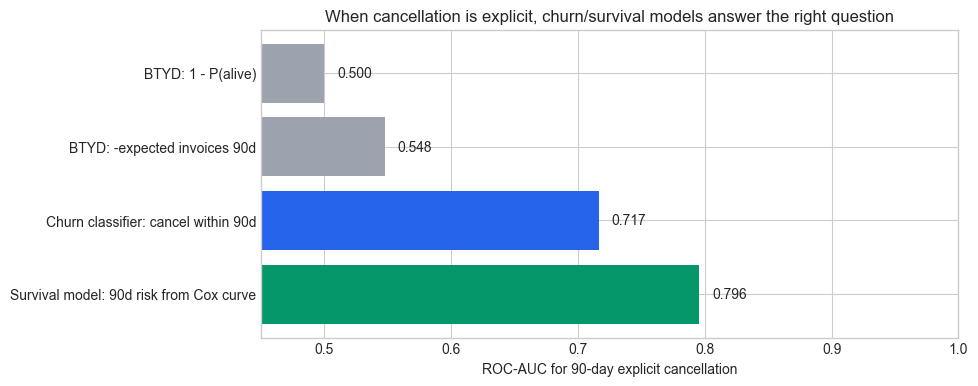

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparison["model"], comparison["test_roc_auc_for_90d_churn"], color=["#059669", "#2563EB", "#9CA3AF", "#9CA3AF"])
ax.set_xlim(0.45, 1.0)
ax.set_xlabel("ROC-AUC for 90-day explicit cancellation")
ax.set_title("When cancellation is explicit, churn/survival models answer the right question")
for i, v in enumerate(comparison["test_roc_auc_for_90d_churn"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.show()

## 9. Churn model vs survival model

A churn classifier and a survival model are cousins, but they are not the same.

| Question | Churn classifier | Survival model |
|---|---|---|
| Target | Event before a fixed horizon | Time until event, plus censoring flag |
| Example | Cancel in next 90 days? | When will the customer cancel? |
| Output | One probability for one window | A full curve, so many horizons are possible |
| Censoring | Awkward unless horizon is fully observed | Native part of the model |
| Best for | Campaign targeting, simple operational lists | Retention curves, timing, multiple horizons, incomplete follow-up |

If the business says, "Give me a list for next month," a churn classifier is often enough.

If the business says, "How does risk evolve over time, and how many customers will remain subscribed at 30, 90, and 180 days?" use survival analysis.

## 10. Decision guide

Use this rule of thumb:

- **Use BTYD** when customers do not cancel and you only observe repeat purchase behavior.
- **Use a churn classifier** when you need a fixed-horizon probability such as `cancel in next 90 days`.
- **Use survival analysis** when timing and censoring matter, or when you need probabilities across multiple future horizons.

For the synthetic subscription business, BTYD performed poorly because monthly invoices are not independent buying decisions. They are billing artifacts of an active contract.

The right target is explicit cancellation.

## Final consultant summary

A polished explanation to a stakeholder would be:

> BTYD is designed for non-contractual repeat purchase settings where churn is hidden. In our subscription business, churn is explicit: customers cancel. Because invoices are mechanically generated while the contract is active, standard BTYD mostly learns tenure and billing cadence. A churn classifier directly estimates cancellation within the campaign window, while a survival model estimates the full time-to-cancel curve and handles customers who have not canceled yet. For this use case, churn or survival should be the first modeling choice.

The modeling lesson is simple but important: choose the model that matches how the business observes the event.